# Explainable AI dengan SHAP — Kelompok 3

**Mata Kuliah:** Machine Learning (Kelas C) — Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Bapak menyampaikan di perkuliahan bahwa sistem yang baik tidak cukup hanya bisa
mengklasifikasi atau memprediksi — ia juga harus dapat **memberikan penjelasan**.
Notebook ini mengerjakan bagian itu.

SHAP (*SHapley Additive exPlanations*) berasal dari teori permainan kooperatif. Ia
menjawab pertanyaan: dari sekian faktor yang dimiliki pasien ini, **berapa besar
sumbangan masing-masing** terhadap keputusan model?

Dua tingkat penjelasan yang dihasilkan:

- **Global** — faktor apa yang paling menentukan bagi model secara keseluruhan
- **Individual** — mengapa pasien *tertentu* ini ditandai berisiko

Pertanyaan kunci yang harus dijawab di akhir: **apakah faktor yang dianggap penting
oleh model sejalan dengan faktor risiko stroke yang diketahui secara medis?** Kalau
tidak sejalan, itu tanda ada yang salah — bukan tanda model menemukan hal baru.


## 1. Persiapan

In [1]:
# SHAP tidak selalu tersedia bawaan. Dipasang hanya kalau memang belum ada.
try:
    import shap
    print("shap sudah tersedia:", shap.__version__)
except ImportError:
    !pip install -q shap
    import shap
    print("shap terpasang:", shap.__version__)

/home/ravi/.cache/uv/archive-v0/0zNUTsPM2tY3POif/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap sudah tersedia: 0.52.0


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42


def muat_data_stroke(seed=SEED):
    """Preprocessing identik dengan notebook 04. Sengaja disalin ulang supaya
    notebook ini tetap bisa dijalankan sendiri di Colab."""
    url = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
           "tutorials/dataset/healthcare-dataset-stroke-data.csv")
    fitur_imp = ["age", "hypertension", "heart_disease", "avg_glucose_level",
                 "gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

    d = pd.read_csv(url).drop(columns=["id"])
    d = d[d.gender != "Other"].copy()

    kosong = d.bmi.isna()
    if kosong.any():
        latih = d[~kosong]
        X_l = pd.get_dummies(latih[fitur_imp], drop_first=True)
        m = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=seed)).fit(X_l, latih.bmi)
        X_k = pd.get_dummies(d[kosong][fitur_imp], drop_first=True).reindex(
            columns=X_l.columns, fill_value=0)
        d.loc[kosong, "bmi"] = m.predict(X_k)

    X = pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True)
    return X, d.stroke


X, y = muat_data_stroke()
X_latih, X_sisa, y_latih, y_sisa = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_uji, y_val, y_uji = train_test_split(
    X_sisa, y_sisa, test_size=0.50, stratify=y_sisa, random_state=SEED)

print("Latih:", X_latih.shape, "| Validasi:", X_val.shape, "| Uji:", X_uji.shape)

Latih: (3576, 15) | Validasi: (766, 15) | Uji: (767, 15)


### Membangun ulang kedua model final

Hyperparameter diambil dari hasil GridSearchCV di notebook `05`.

Satu perbedaan perlakuan yang disengaja: **Logistic Regression dilatih pada data
terskala**, karena model linear memang memerlukannya. **Gradient Boosting dilatih pada
data asli**, karena pohon keputusan tidak terpengaruh skala — dan hasilnya grafik SHAP
untuk Gradient Boosting bisa dibaca dalam satuan aslinya (tahun, mg/dL), jauh lebih
mudah ditafsirkan.

In [3]:
penskala = StandardScaler().fit(X_latih)
X_latih_s = pd.DataFrame(penskala.transform(X_latih), columns=X.columns, index=X_latih.index)
X_uji_s = pd.DataFrame(penskala.transform(X_uji), columns=X.columns, index=X_uji.index)
X_val_s = pd.DataFrame(penskala.transform(X_val), columns=X.columns, index=X_val.index)

# parameter dari GridSearchCV notebook 05
model_lr = LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                              max_iter=5000, random_state=SEED).fit(X_latih_s, y_latih)
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
                                      max_depth=2, random_state=SEED).fit(X_latih, y_latih)

# ambang ditetapkan dari data validasi, sama seperti notebook 05
def ambang_recall(y, skor, target=0.80):
    for t in sorted(np.unique(np.round(skor, 4)), reverse=True):
        if recall_score(y, (skor >= t).astype(int)) >= target:
            return t
    return float(np.min(skor))

t_lr = ambang_recall(y_val, model_lr.predict_proba(X_val_s)[:, 1])
t_gb = ambang_recall(y_val, model_gb.predict_proba(X_val)[:, 1])
print(f"Ambang Logistic Regression: {t_lr:.4f}")
print(f"Ambang Gradient Boosting  : {t_gb:.4f}")

Ambang Logistic Regression: 0.0530
Ambang Gradient Boosting  : 0.0602


## 2. Penjelasan Global — Logistic Regression

`LinearExplainer` dipakai karena modelnya linear. Perhitungannya persis, bukan
perkiraan, dan selesai dalam hitungan detik.

Background dataset has 3576 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3576 when initializing the masker.


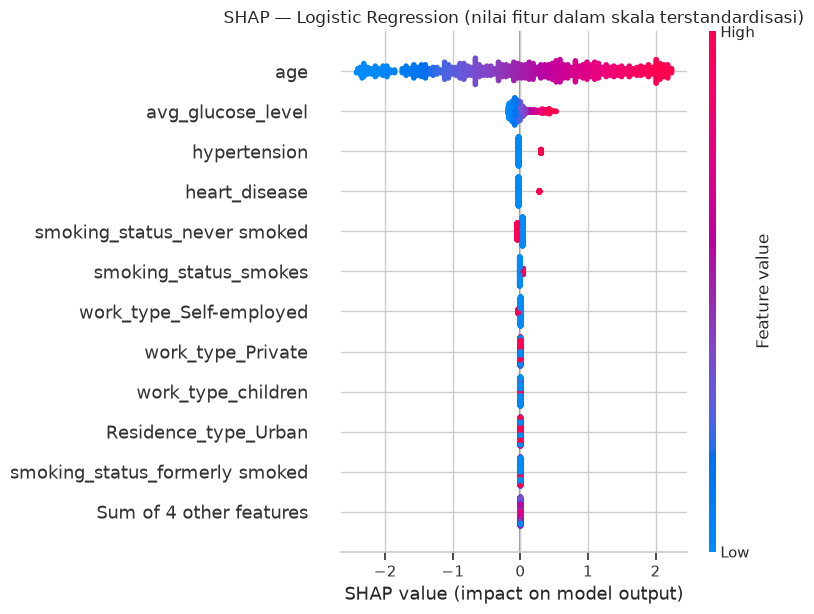

In [4]:
penjelas_lr = shap.LinearExplainer(model_lr, X_latih_s)
nilai_lr = penjelas_lr(X_uji_s)

shap.plots.beeswarm(nilai_lr, max_display=12, show=False)
plt.title("SHAP — Logistic Regression (nilai fitur dalam skala terstandardisasi)")
plt.tight_layout(); plt.show()

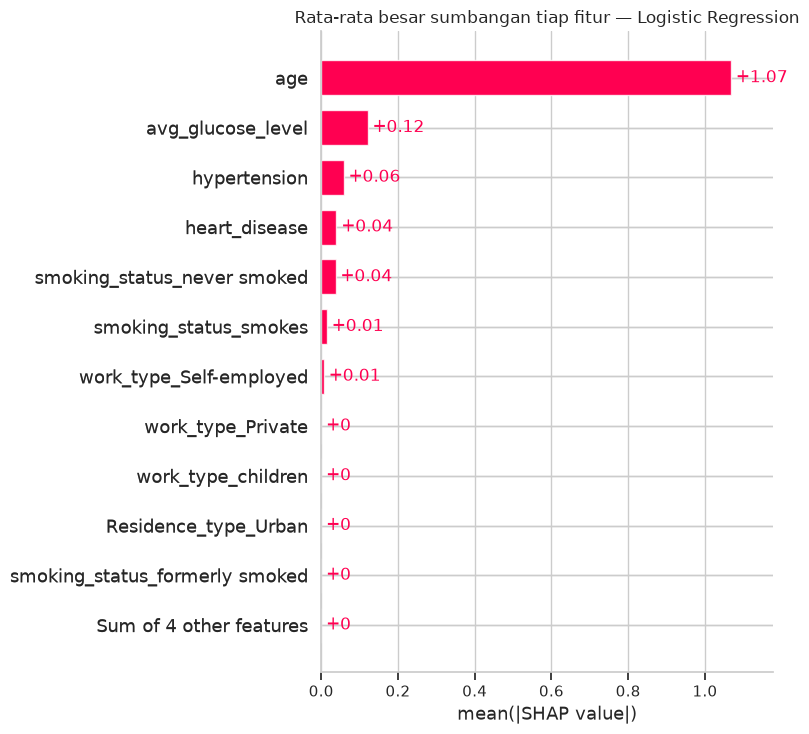

In [5]:
shap.plots.bar(nilai_lr, max_display=12, show=False)
plt.title("Rata-rata besar sumbangan tiap fitur — Logistic Regression")
plt.tight_layout(); plt.show()

## 3. Penjelasan Global — Gradient Boosting

`TreeExplainer` dipakai karena modelnya berbasis pohon. Sama cepatnya, dan karena
model ini dilatih pada data asli, sumbu warnanya bisa dibaca dalam satuan sebenarnya.

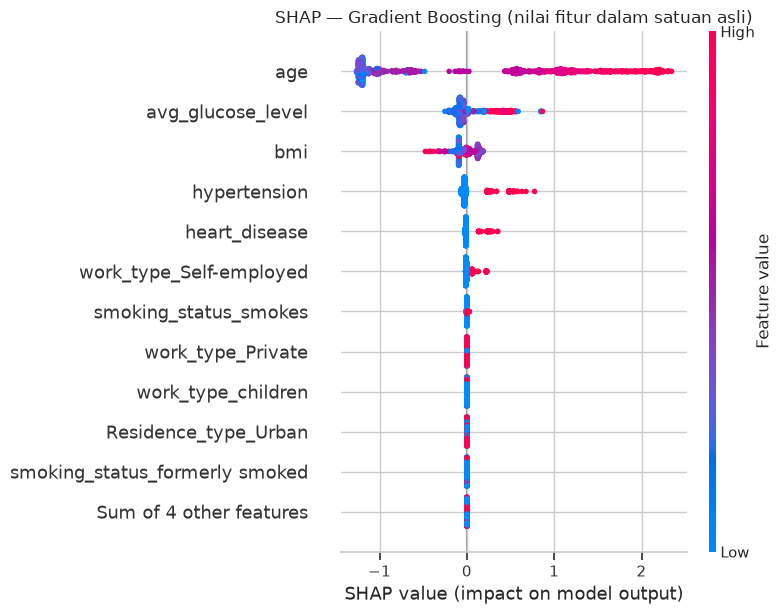

In [6]:
penjelas_gb = shap.TreeExplainer(model_gb)
nilai_gb = penjelas_gb(X_uji)

shap.plots.beeswarm(nilai_gb, max_display=12, show=False)
plt.title("SHAP — Gradient Boosting (nilai fitur dalam satuan asli)")
plt.tight_layout(); plt.show()

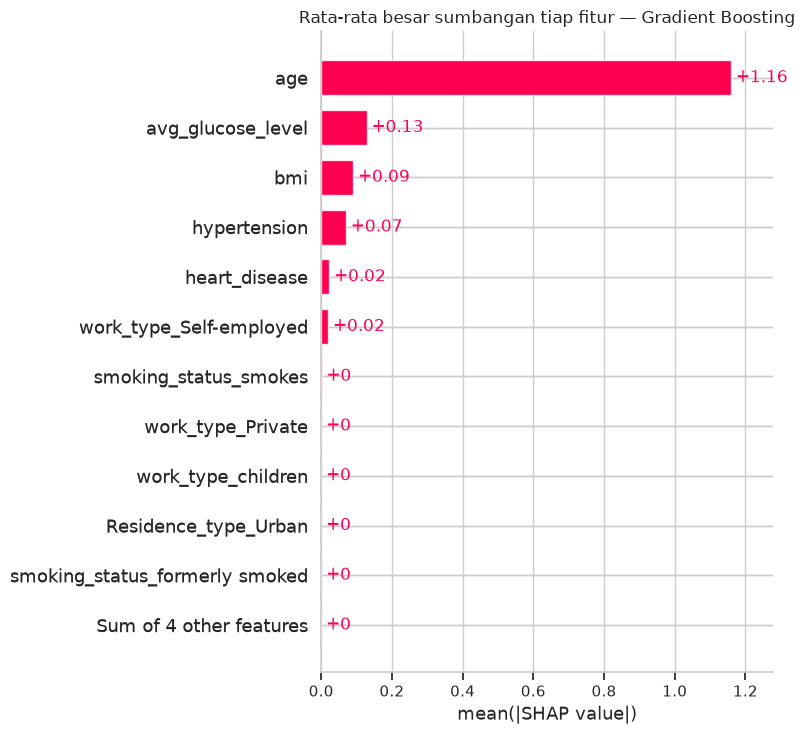

In [7]:
shap.plots.bar(nilai_gb, max_display=12, show=False)
plt.title("Rata-rata besar sumbangan tiap fitur — Gradient Boosting")
plt.tight_layout(); plt.show()

## 4. Apakah Ketiga Cara Sepakat?

SHAP bukan satu-satunya cara mengetahui fitur penting. Ada pula koefisien Logistic
Regression dan `feature_importances_` bawaan Gradient Boosting.

Kalau ketiganya sepakat, keyakinan kita bertambah. Kalau berselisih, itu justru
pertanyaan yang menarik untuk dibahas.

In [8]:
peringkat = pd.DataFrame({
    "SHAP (LogReg)": np.abs(nilai_lr.values).mean(0),
    "SHAP (GradBoost)": np.abs(nilai_gb.values).mean(0),
    "|Koefisien| LogReg": np.abs(model_lr.coef_[0]),
    "Importance GradBoost": model_gb.feature_importances_,
}, index=X.columns)

# diubah jadi peringkat supaya bisa dibandingkan meski satuannya berbeda
urutan = peringkat.rank(ascending=False).astype(int)
urutan["rata-rata peringkat"] = urutan.mean(axis=1).round(2)
urutan.sort_values("rata-rata peringkat").head(10)

,SHAP (LogReg),SHAP (GradBoost),|Koefisien| LogReg,Importance GradBoost,rata-rata peringkat
age,1,1,1,1,1.00
avg_glucose_level,2,2,2,2,2.00
hypertension,3,4,3,4,3.50
heart_disease,4,5,4,5,4.50
smoking_status_smokes,6,7,6,6,6.25
work_type_Self-employed,7,6,7,7,6.75
bmi,11,3,11,3,7.00
smoking_status_never smoked,5,11,5,11,8.00
work_type_Never_worked,11,11,11,11,11.00
ever_married_Yes,11,11,11,11,11.00


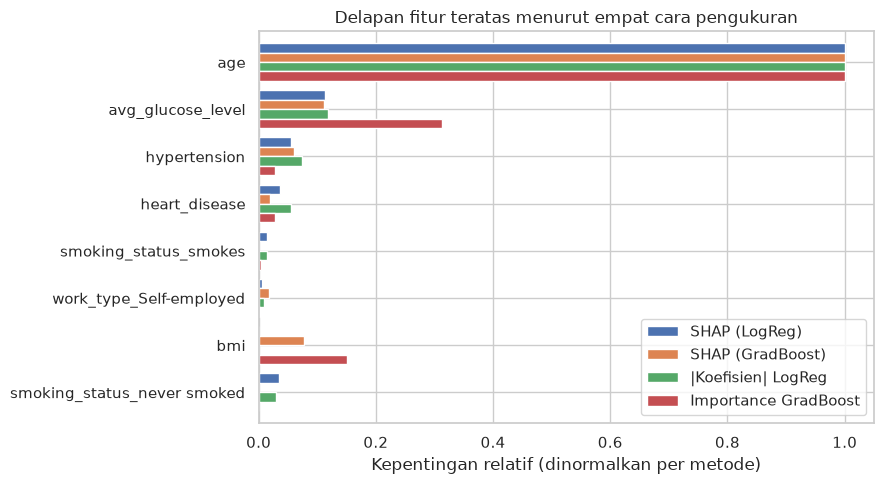

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
lima = urutan.sort_values("rata-rata peringkat").head(8).index
(peringkat.loc[lima] / peringkat.loc[lima].max()).plot(kind="barh", ax=ax, width=.8)
ax.set_xlabel("Kepentingan relatif (dinormalkan per metode)")
ax.set_title("Delapan fitur teratas menurut empat cara pengukuran")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Penjelasan Individual

Inilah yang Bapak maksud dengan sistem yang mampu memberi penjelasan, bukan sekadar
memberi label. Untuk pasien tertentu, SHAP menguraikan faktor apa yang mendorong
model menganggapnya berisiko.

In [10]:
prob_gb = model_gb.predict_proba(X_uji)[:, 1]

# satu pasien dengan risiko tertinggi, satu dengan risiko terendah
paling_berisiko = int(np.argmax(prob_gb))
paling_aman = int(np.argmin(prob_gb))

for label, i in [("PALING BERISIKO", paling_berisiko), ("PALING AMAN", paling_aman)]:
    print(f"--- Pasien {label}")
    print(f"    probabilitas model : {prob_gb[i]:.4f}  (ambang {t_gb:.4f})")
    print(f"    kenyataan          : {'terkena stroke' if y_uji.iloc[i] == 1 else 'tidak stroke'}")
    tampil = X_uji.iloc[i][["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]]
    print("   ", tampil.to_dict())
    print()

--- Pasien PALING BERISIKO
    probabilitas model : 0.2954  (ambang 0.0602)
    kenyataan          : tidak stroke
    {'age': 81.0, 'avg_glucose_level': 59.28, 'bmi': 28.1, 'hypertension': 1, 'heart_disease': 1}

--- Pasien PALING AMAN
    probabilitas model : 0.0053  (ambang 0.0602)
    kenyataan          : tidak stroke
    {'age': 26.0, 'avg_glucose_level': 91.88, 'bmi': 24.9, 'hypertension': 0, 'heart_disease': 0}



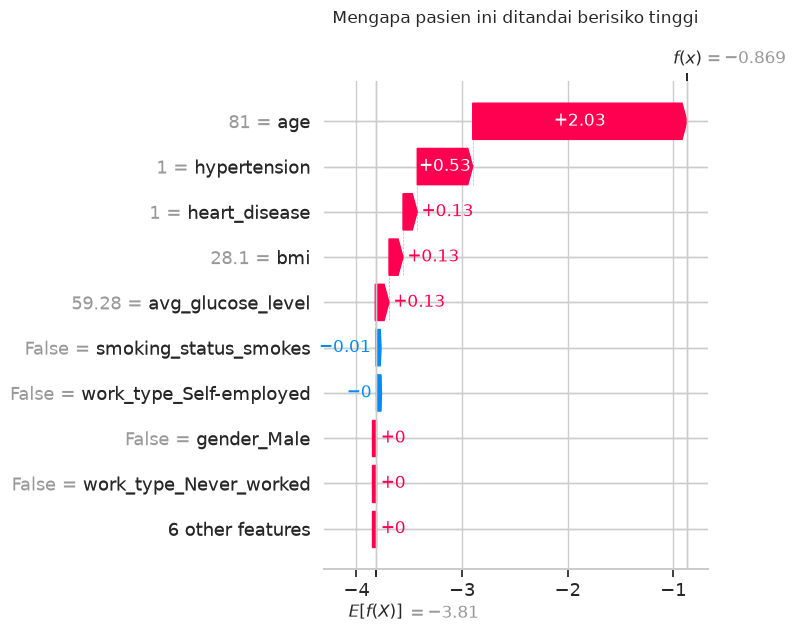

In [11]:
shap.plots.waterfall(nilai_gb[paling_berisiko], max_display=10, show=False)
plt.title("Mengapa pasien ini ditandai berisiko tinggi", pad=20)
plt.tight_layout(); plt.show()

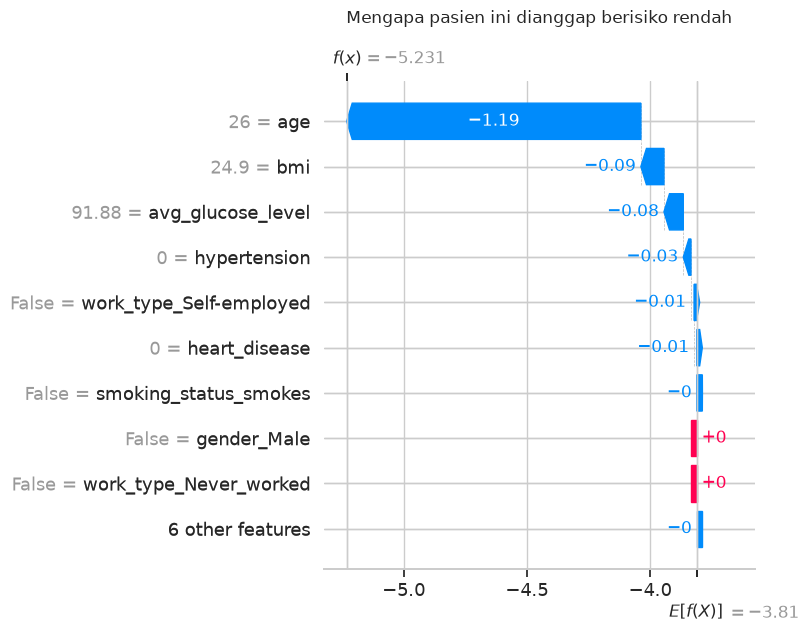

In [12]:
shap.plots.waterfall(nilai_gb[paling_aman], max_display=10, show=False)
plt.title("Mengapa pasien ini dianggap berisiko rendah", pad=20)
plt.tight_layout(); plt.show()

### Menerjemahkan ke bahasa manusia

Nilai SHAP berada dalam satuan *log-odds*, yang tidak berarti apa-apa bagi pasien
maupun tenaga medis. Fungsi berikut menerjemahkannya menjadi kalimat biasa — inilah
bentuk Explainable AI yang benar-benar berguna di ruang praktik.

In [13]:
NAMA_ENAK = {
    "age": "usia", "avg_glucose_level": "kadar glukosa rata-rata", "bmi": "BMI",
    "hypertension": "riwayat hipertensi", "heart_disease": "riwayat penyakit jantung",
    "ever_married_Yes": "status pernah menikah", "gender_Male": "jenis kelamin laki-laki",
    "Residence_type_Urban": "tinggal di perkotaan",
    "smoking_status_smokes": "perokok aktif",
    "smoking_status_formerly smoked": "mantan perokok",
    "smoking_status_never smoked": "tidak pernah merokok",
    "work_type_Private": "pekerja swasta", "work_type_Self-employed": "wiraswasta",
    "work_type_children": "masih anak-anak", "work_type_Never_worked": "belum pernah bekerja",
}


def jelaskan(i, n=4):
    """Ubah nilai SHAP satu pasien menjadi penjelasan berbahasa Indonesia."""
    sv = pd.Series(nilai_gb.values[i], index=X.columns)
    prob = prob_gb[i]
    status = "BERISIKO" if prob >= t_gb else "risiko rendah"

    naik = sv[sv > 0].sort_values(ascending=False).head(n)
    turun = sv[sv < 0].sort_values().head(n)

    baris = [f"Pasien ini dinilai {status} (probabilitas {prob:.1%}, ambang {t_gb:.1%})."]
    if len(naik):
        baris.append("\nYang MENAIKKAN penilaian risiko:")
        for f, v in naik.items():
            baris.append(f"  - {NAMA_ENAK.get(f, f)} = {X_uji.iloc[i][f]:g}  (sumbangan +{v:.3f})")
    if len(turun):
        baris.append("\nYang MENURUNKAN penilaian risiko:")
        for f, v in turun.items():
            baris.append(f"  - {NAMA_ENAK.get(f, f)} = {X_uji.iloc[i][f]:g}  (sumbangan {v:.3f})")
    baris.append("\nCatatan: ini alat bantu skrining, BUKAN diagnosis. "
                 "Keputusan medis tetap di tangan dokter.")
    return "\n".join(baris)


print(jelaskan(paling_berisiko))
print("\n" + "=" * 70 + "\n")
print(jelaskan(paling_aman))

Pasien ini dinilai BERISIKO (probabilitas 29.5%, ambang 6.0%).

Yang MENAIKKAN penilaian risiko:
  - usia = 81  (sumbangan +2.029)
  - riwayat hipertensi = 1  (sumbangan +0.525)
  - riwayat penyakit jantung = 1  (sumbangan +0.135)
  - BMI = 28.1  (sumbangan +0.133)

Yang MENURUNKAN penilaian risiko:
  - perokok aktif = 0  (sumbangan -0.007)
  - wiraswasta = 0  (sumbangan -0.004)

Catatan: ini alat bantu skrining, BUKAN diagnosis. Keputusan medis tetap di tangan dokter.


Pasien ini dinilai risiko rendah (probabilitas 0.5%, ambang 6.0%).

Yang MENURUNKAN penilaian risiko:
  - usia = 26  (sumbangan -1.194)
  - BMI = 24.9  (sumbangan -0.094)
  - kadar glukosa rata-rata = 91.88  (sumbangan -0.078)
  - riwayat hipertensi = 0  (sumbangan -0.031)

Catatan: ini alat bantu skrining, BUKAN diagnosis. Keputusan medis tetap di tangan dokter.


## 6. Pertanyaan Kunci: Apakah Sejalan dengan Pengetahuan Medis?

Faktor risiko stroke yang sudah mapan dalam literatur kedokteran: **usia**,
**hipertensi**, **penyakit jantung**, **kadar glukosa/diabetes**, dan **merokok**.

Kalau model menempatkan faktor-faktor itu di peringkat atas, artinya ia mempelajari
sesuatu yang nyata. Kalau yang muncul di puncak justru hal seperti jenis pekerjaan atau
tempat tinggal, itu tanda model menangkap kebetulan dalam data, bukan sebab-akibat.

In [14]:
FAKTOR_MEDIS = ["age", "hypertension", "heart_disease", "avg_glucose_level",
                "smoking_status_smokes", "smoking_status_formerly smoked"]

lima_teratas = urutan.sort_values("rata-rata peringkat").head(5).index.tolist()
cocok = [f for f in lima_teratas if f in FAKTOR_MEDIS]

print("Lima fitur terpenting menurut gabungan keempat cara:")
for i, f in enumerate(lima_teratas, 1):
    tanda = "sesuai literatur medis" if f in FAKTOR_MEDIS else "TIDAK ada di daftar faktor risiko mapan"
    print(f"  {i}. {NAMA_ENAK.get(f, f):32} -- {tanda}")

print(f"\nKesesuaian: {len(cocok)} dari 5 fitur teratas merupakan faktor risiko yang mapan.")

Lima fitur terpenting menurut gabungan keempat cara:
  1. usia                             -- sesuai literatur medis
  2. kadar glukosa rata-rata          -- sesuai literatur medis
  3. riwayat hipertensi               -- sesuai literatur medis
  4. riwayat penyakit jantung         -- sesuai literatur medis
  5. perokok aktif                    -- sesuai literatur medis

Kesesuaian: 5 dari 5 fitur teratas merupakan faktor risiko yang mapan.


## 7. Kesimpulan Tugas D

**Yang dikerjakan.** SHAP dijalankan pada kedua model di judul — `LinearExplainer`
untuk Logistic Regression, `TreeExplainer` untuk Gradient Boosting — pada tingkat
global maupun individual, lalu dibandingkan dengan koefisien dan feature importance.

**Nilai praktisnya.** Model kini tidak hanya menjawab "berisiko / tidak berisiko",
tetapi juga menguraikan alasannya dalam kalimat yang bisa dibaca orang awam. Untuk
alat skrining kesehatan, kemampuan ini bukan pelengkap — tanpa penjelasan, tidak ada
tenaga medis yang mau memakai keluaran model yang tidak bisa dipertanggungjawabkan.

**Peringatan yang wajib ditulis di laporan.** SHAP menjelaskan **apa yang dipakai model
untuk memutuskan**, bukan **apa yang menyebabkan stroke**. Keduanya sering tertukar.
Kalau model banyak bersandar pada usia, itu berarti usia berguna untuk *memprediksi*
dalam data ini — bukan bukti hubungan sebab-akibat. Menyimpulkan sebab-akibat dari
nilai SHAP adalah kesalahan penafsiran yang serius.

Notebook berikutnya: `08_validasi_eksternal.ipynb` — notebook terakhir.